In [83]:
import logging, warnings
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import spearmanr, ConstantInputWarning
from tqdm import tqdm
from umap import UMAP
from dtaidistance import dtw, dtw_visualisation as dtwvis
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib
import importlib
import sys

from src.utils import iter_dataset_dirs, load_json
from src.plot_style import apply_plot_style
from src.visualization import plot_mts_corr_density, plot_spi_space_individual, plot_pca, plot_tsne, plot_umap, plot_mts_heatmap

apply_plot_style()
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
warnings.simplefilter("ignore", ConstantInputWarning)


In [82]:
def generate_ar1(T: int, a: float, noise_std: float, seed=None):
    rng = np.random.default_rng(seed)
    X = np.zeros(T)
    for t in range(1, T):
        X[t] = a * X[t-1] + rng.normal(0, noise_std)
    return X

def warp_path(T: int, p: float = 0.5, step: int = 1, seed=None):
    """Generate a random monotone warping path from (0,0) to (T-1, T-1)."""
    rng = np.random.default_rng(seed)
    x, y = 0, 0
    path = [(x, y)]
    while x < T - 1 or y < T - 1:
        if x >= T - 1:
            y = min(y + step, T - 1)
        elif y >= T - 1:
            x = min(x + step, T - 1)
        else:
            if rng.random() < p:
                x = min(x + step, T - 1)
            else:
                y = min(y + step, T - 1)
        path.append((x, y))
    return np.array(path, dtype=int)

def warp_path_geom(T: int, p: float = 0.5, seed=None):
    """Random monotone warping path with geometric step size.

    step ~ Geometric(p_step) on {1, 2, ...}.
    """
    rng = np.random.default_rng(seed)
    x, y = 0, 0
    path = [(x, y)]
    while x < T - 1 or y < T - 1:
        step = int(np.clip(rng.geometric(p), 1, T))
        if x >= T - 1:
            y = min(y + step, T - 1)
        elif y >= T - 1:
            x = min(x + step, T - 1)
        else:
            if rng.integers(2) == 0:
                x = min(x + step, T - 1)
            else:
                y = min(y + step, T - 1)
        path.append((x, y))
    return np.asarray(path, dtype=int)

def warp_path_rebound(T: int, p: float = 0.5, p_step: float = 0.5, seed=None):
    """
    Rebound warping path:
    - step size ~ Geometric(p)
    - at each cycle, draw u ~ Uniform[0,1]
      if u < p_step: do R(step) then U(step), or U(step) then R(step) with equal probability
      else:          continue on identity line (x == y) for 1 step

    This guarantees you return to the identity line (x == y)
    after each RU/UR cycle.
    """
    rng = np.random.default_rng(seed)
    x, y = 0, 0
    path = [(x, y)]

    # x == y is preserved after each full RU/UR cycle
    while x < T - 1:
        max_step = T - 1 - x
        step = int(min(rng.geometric(p), max_step))
        u = rng.uniform(0.0, 1.0)

        if u < p_step:
            if rng.integers(2) == 0:
                # R then U
                x += step
                path.append((x, y))
                y += step
                path.append((x, y))
            else:
                # U then R
                y += step
                path.append((x, y))
                x += step
                path.append((x, y))
        else:
            x += 1
            y += 1
            path.append((x, y))

    return np.asarray(path, dtype=int)

def path_to_mapping(path: np.ndarray, T: int):
    n = np.zeros(T, dtype=int)
    s = np.zeros(T, dtype=float)
    for x, y in path:
        n[y] += 1
        s[y] += x
    m = np.zeros(T, dtype=int)
    for y in range(T):
        m[y] = int(round(s[y] / n[y])) if n[y] > 0 else 0
    m = np.clip(m, 0, T - 1)
    m = np.maximum.accumulate(m)
    return m

def warp_series(X_orig: np.ndarray, mapping: np.ndarray):
    return X_orig[mapping].copy()

def plot_warp(X, X_warp, path, title_left: str = "Original vs Warped Time Series", title_right: str = "Warp Path - geom"):
    """Plot original/warped signals and warp path in (t_orig, t_warp) space."""
    X = np.asarray(X)
    X_warp = np.asarray(X_warp)
    path = np.asarray(path)
    if path.ndim != 2 or path.shape[1] != 2:
        raise ValueError("path must be shape (n, 2)")

    T = len(X)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

    # Left: Original vs Warped signals
    ax = axes[0]
    ax.plot(X, label="Original", color="gray",lw=1.0)
    ax.plot(X_warp, label="Warped", lw=1.0, alpha=0.8, color="purple")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$X(t)$")
    ax.set_title(title_left)
    ax.legend()

    # Right: Warp path in (t_orig, t_warp) space
    ax = axes[1]
    ax.plot([0, T - 1], [0, T - 1], lw=0.75, alpha=0.5, color="gray", label="Identity")
    ax.plot(path[:, 0], path[:, 1], lw=1, alpha=0.8, label="Warp path", color="purple")
    ax.set_xlabel(r"$t_{\mathrm{orig}}$")
    ax.set_ylabel(r"$t_{\mathrm{warp}}$")
    ax.set_title(title_right)
    ax.set_aspect("equal")
    ax.legend()
    fig.tight_layout()
    plt.show()
    return fig, axes

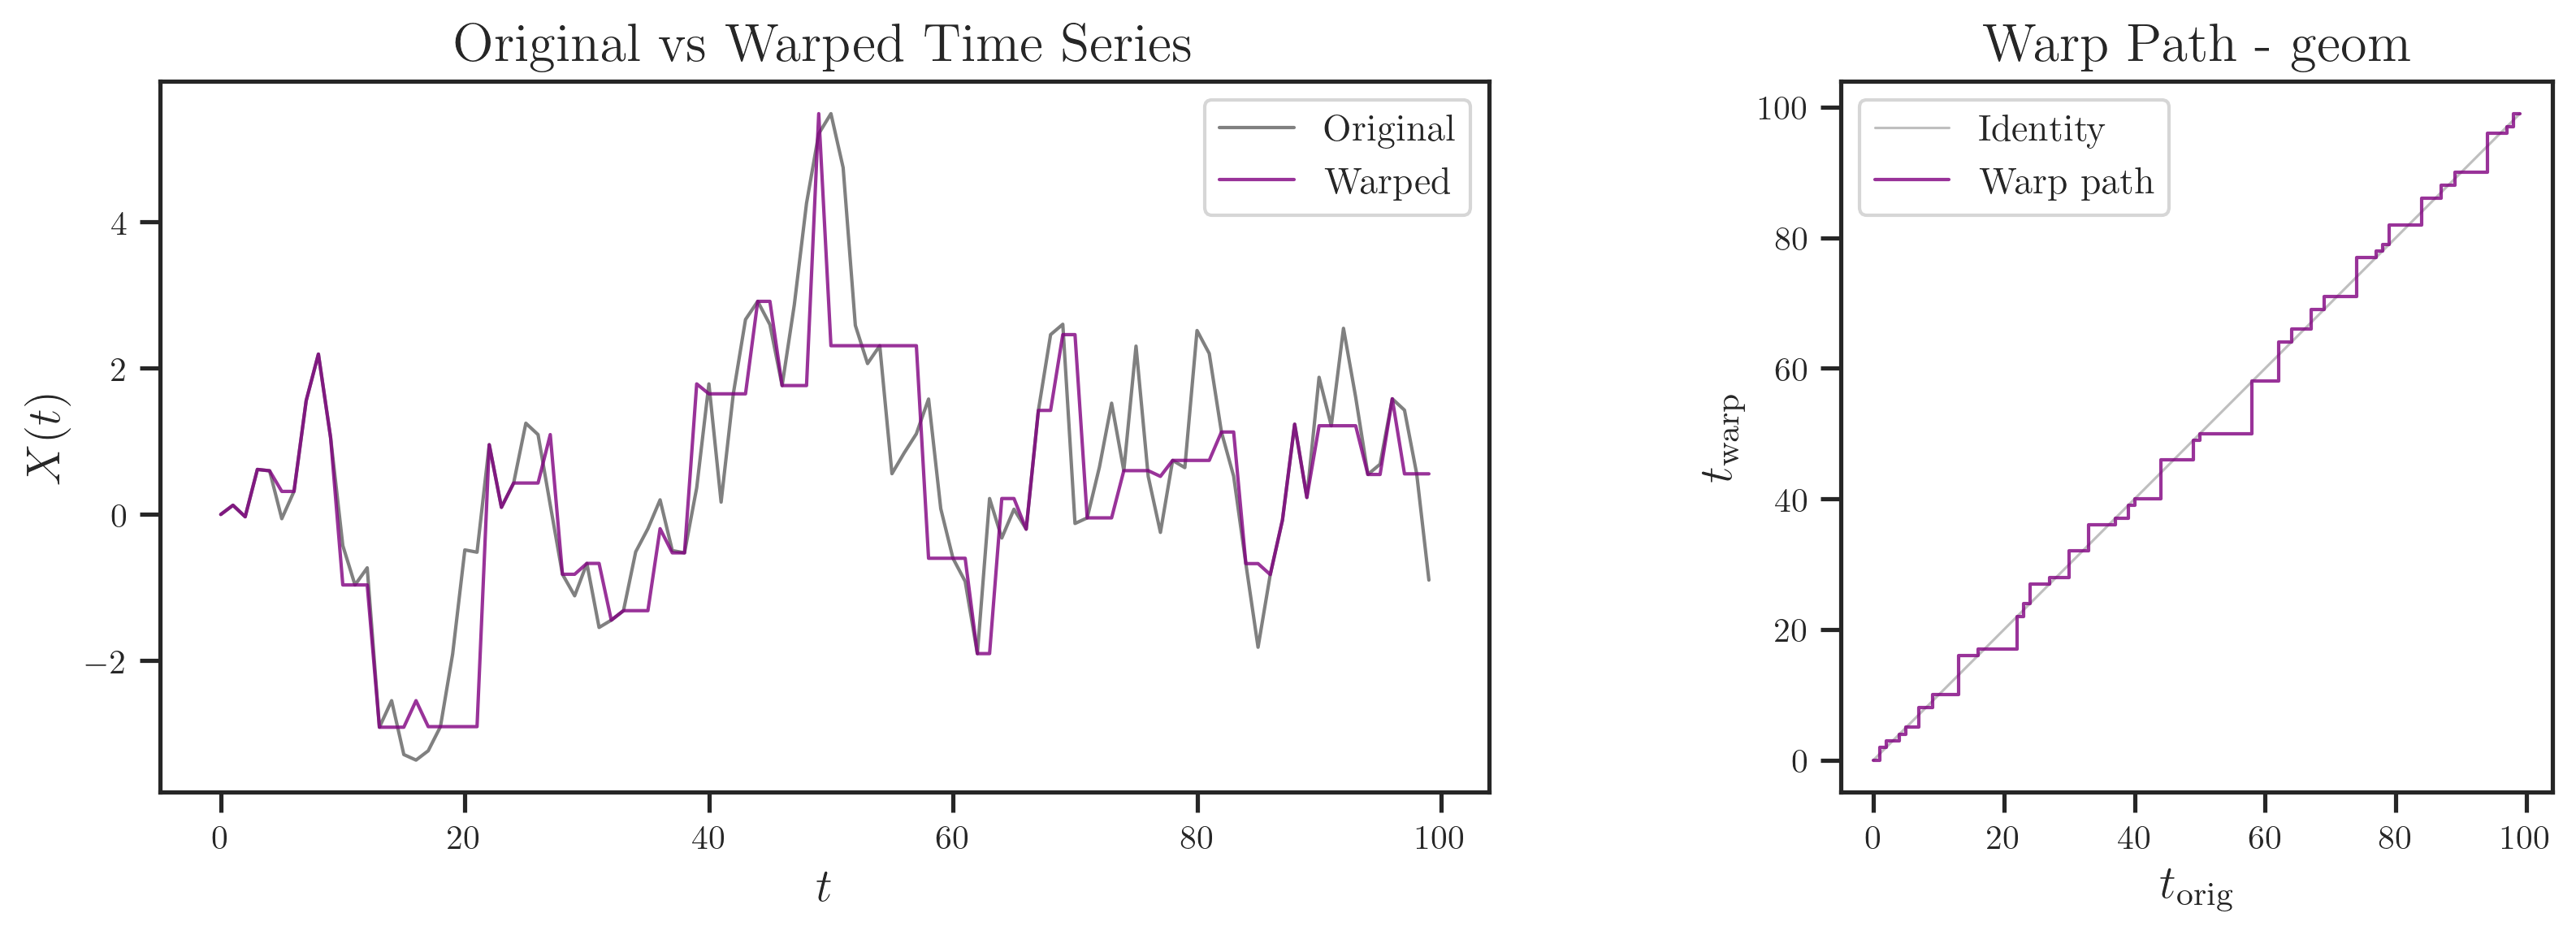

Computed distances:
pdist_euclidean:    9.546990253986579
dtw:                5.795867013937626
dtw_sakoe_chiba:    5.795867013937626


In [84]:
from matplotlib.ticker import ScalarFormatter

if __name__ == "__main__":
    T = 100
    p = 0.5
    p_step = 1

    X = generate_ar1(T=T, a=0.8, noise_std=1.0, seed=0)
    euclidean_vals = []
    dtw_vals = []

    # path_true = warp_path_geom(T=T, p=p) # can include seed=42 for reproducebaility
    path_true = warp_path_rebound(T=T, p=p, p_step=p_step)
    mapping = path_to_mapping(path_true, T=T)
    X_warp = warp_series(X, mapping)

    dtw_dist, paths = dtw.warping_paths(X, X_warp, use_c=True)
    path_dtw = dtw.best_path(paths)

    ed = np.linalg.norm(X - X_warp)
    euclidean_vals.append(ed)
    dtw_vals.append(dtw_dist)

    plot_warp(X, X_warp, path_true)

    print("Computed distances:")
    euclidean = np.linalg.norm(X - X_warp)  # pdist_euclidean 
    print(f"pdist_euclidean:    {euclidean}")
    dtw_dist = dtw.distance(X, X_warp, use_c=True)
    print(f"dtw:                {dtw_dist}")
    dtw_sakoe_chiba = dtw.distance(X, X_warp, window=10, use_c=True)
    print(f"dtw_sakoe_chiba:    {dtw_sakoe_chiba}")

    # dtw:                   222.19335844397546

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dtaidistance import dtw, dtw_visualisation as dtwvis


def _to_dtwvis_path(path):
    """Convert path to list-of-tuples format expected by dtw_visualisation."""
    if path is None:
        return None
    if isinstance(path, (int, np.integer)) and int(path) == -1:
        return -1
    arr = np.asarray(path)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("path must be shape (n, 2), a list of tuples, None, or -1")
    return [tuple(map(int, p)) for p in arr]

def compute_dtw(s_orig, s_warp, *, use_c=True, **warping_paths_kwargs):
    """Compute DTW distance, paths matrix, and best path."""
    dtw_dist, paths = dtw.warping_paths(s_orig, s_warp, use_c=use_c, **warping_paths_kwargs)
    path_dtw = dtw.best_path(paths)
    return dtw_dist, paths, path_dtw

def plot_dtw_alignment(
    s_orig,
    s_warp,
    path,
    *,
    series_line_options={"linewidth": 1.0},
    warping_line_options={"linewidth": 0.5, "color": "purple", "alpha": 0.35},
    orig_style={"color": "gray", "linewidth": 1.3, "alpha": 0.9},
    warp_style={"color": "royalblue", "linewidth": 1.3, "alpha": 0.9},
    connection_style={"color": "purple", "alpha": 0.25, "linewidth": 0.4},
    ylabels=(r"$X_{\mathrm{orig}}$", r"$X_{\mathrm{warp}}$"),
    title=None,
):
    fig, axs = dtwvis.plot_warping(
        s_orig, s_warp, _to_dtwvis_path(path),
        series_line_options=series_line_options,
        warping_line_options=warping_line_options,
    )

    axs[0].lines[0].set(**orig_style)
    axs[1].lines[0].set(**warp_style)
    for art in fig.artists:
        art.set(**connection_style)

    axs[0].set_ylabel(ylabels[0])
    axs[1].set_ylabel(ylabels[1])
    axs[0].set_xticks([])
    axs[1].set_xlabel(rf"$t_{{\mathrm{{warp}}}}$")

    for ax in axs:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    axs[0].spines["bottom"].set_visible(False)

    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return fig, axs

def plot_dtw_warping_matrix(
    s_orig,
    s_warp,
    paths,
    *,
    path,
    true_path,
    showlegend=True,
    matshow_kwargs={"cmap": "viridis", "interpolation": "nearest"},
    dtw_path_style={"color": "purple", "linewidth": 3, "marker": "", "markersize": 2, "alpha": 0.9, "label": "Warped Path"},
    true_path_style={"color": "cyan", "linewidth": 0.8, "alpha": 0.8, "label": "Generating warp"},
    top_marginal_style={"color": "royalblue", "marker": "", "markersize": 2.0, "linewidth": 1.2, "alpha": 0.85},
    left_marginal_style={"color": "gray", "marker": "", "markersize": 2.0, "linewidth": 1.2, "alpha": 0.85},
    top_position_delta={"dy": 0.01, "h": 0.9},
    left_position_delta={"w": 0.9},
    xlabel=r"$t_{\mathrm{warp}}$",
    ylabel=r"$t_{\mathrm{orig}}$",
    colorbar_position=(0.92, 0.20, 0.02, 0.60),
    colorbar_tick_params={"labelsize": 8},
    matrix_title="",
    matrix_legend_kwargs={"loc": "upper right", "fontsize": 10},
):
    fig, axes = dtwvis.plot_warpingpaths(
        s_orig, s_warp, paths,
        path=_to_dtwvis_path(path),
        showlegend=showlegend,
        matshow_kwargs=matshow_kwargs,
    )
    ax_info, ax_top, ax_left, ax_mat = axes[:4]
    ax_cbar = axes[4] if len(axes) > 4 else None

    # DTW best path style
    ax_mat.lines[0].set(**dtw_path_style)

    # Generating warp overlay
    tp = np.asarray(true_path)
    ax_mat.plot(tp[:, 1], tp[:, 0], **true_path_style)

    # Marginal series styling
    ax_top.lines[0].set(**top_marginal_style)
    ax_left.lines[0].set(**left_marginal_style)

    # Marginal axis position tweaks
    p = ax_top.get_position()
    ax_top.set_position([
        p.x0 + top_position_delta.get("dx", 0.0),
        p.y0 + top_position_delta.get("dy", 0.0),
        p.width * top_position_delta.get("w", 1.0),
        p.height * top_position_delta.get("h", 1.0),
    ])
    p = ax_left.get_position()
    ax_left.set_position([
        p.x0 + left_position_delta.get("dx", 0.0),
        p.y0 + left_position_delta.get("dy", 0.0),
        p.width * left_position_delta.get("w", 1.0),
        p.height * left_position_delta.get("h", 1.0),
    ])

    ax_mat.set_xlabel(xlabel)
    ax_mat.set_ylabel(ylabel)
    ax_mat.set_title(matrix_title)
    ax_mat.legend(**matrix_legend_kwargs)

    if ax_cbar is not None:
        ax_cbar.set_position(colorbar_position)
        ax_cbar.tick_params(**colorbar_tick_params)

    ax_mat.invert_yaxis()
    ax_mat.xaxis.tick_bottom()

    return fig, axes

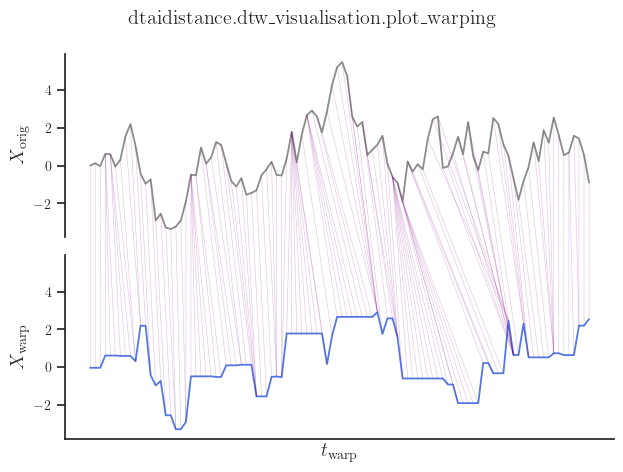

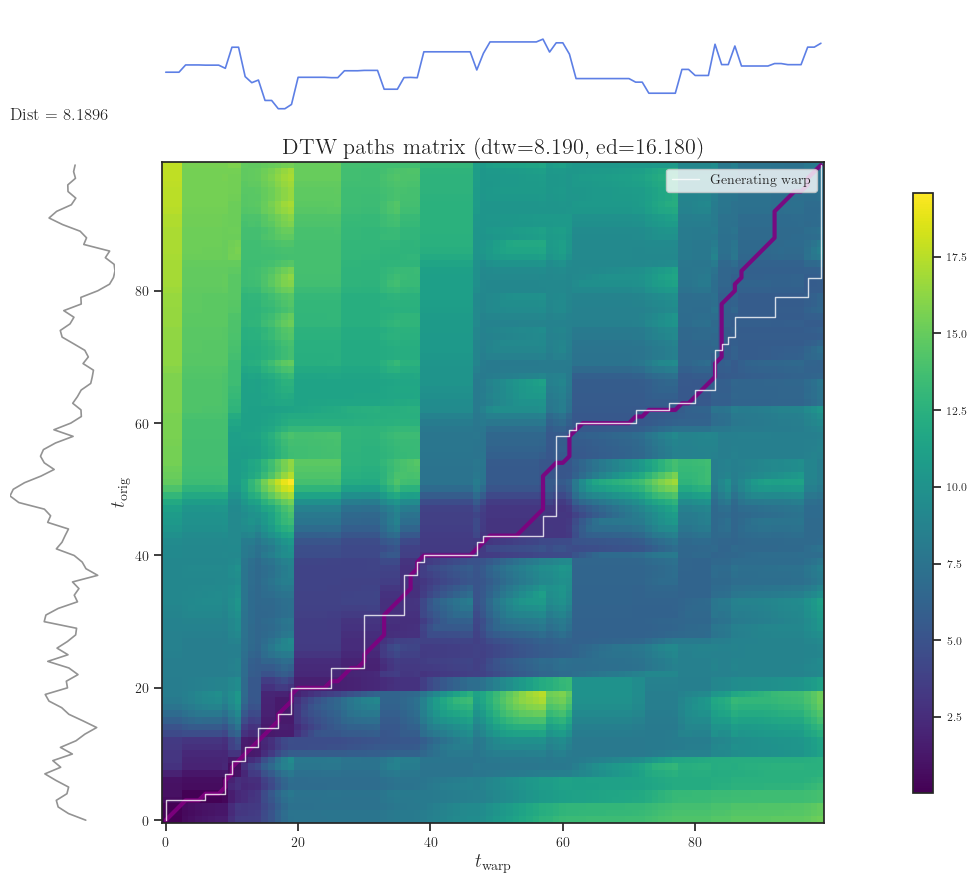

In [20]:
ed = np.linalg.norm(X - X_warp)
dtw_dist, paths, path_dtw = compute_dtw(X, X_warp, use_c=True)

# 1) Alignment plot
fig_warp, axs_warp = plot_dtw_alignment(
    X, X_warp, path_dtw,
    title="dtaidistance.dtw_visualisation.plot_warping",
)

# 2) Warping matrix plot
fig_paths, axes_paths = plot_dtw_warping_matrix(
    X, X_warp, paths,
    path=path_dtw,
    showlegend=True,
    matshow_kwargs={"cmap": "viridis", "interpolation": "nearest"},
    dtw_path_style={"color": "purple", "linewidth": 3, "marker": "", "markersize": 2, "alpha": 0.9},
    true_path=path_true,
    true_path_style={"color": "white", "linewidth": 1, "alpha": 0.8, "label": "Generating warp"},
    top_marginal_style={"color": "royalblue", "marker": "", "markersize": 2.0, "linewidth": 1.2, "alpha": 0.85},
    left_marginal_style={"color": "gray", "marker": "", "markersize": 2.0, "linewidth": 1.2, "alpha": 0.85},
    top_position_delta={"dy": 0.01, "h": 0.9},
    left_position_delta={"w": 0.9},
    colorbar_position=[0.92, 0.20, 0.02, 0.60],
    matrix_title=f"DTW paths matrix (dtw={dtw_dist:.3f}, ed={ed:.3f})",
    matrix_legend_kwargs={"loc": "upper right", "fontsize": 10},
)
plt.show()


###### old plotting

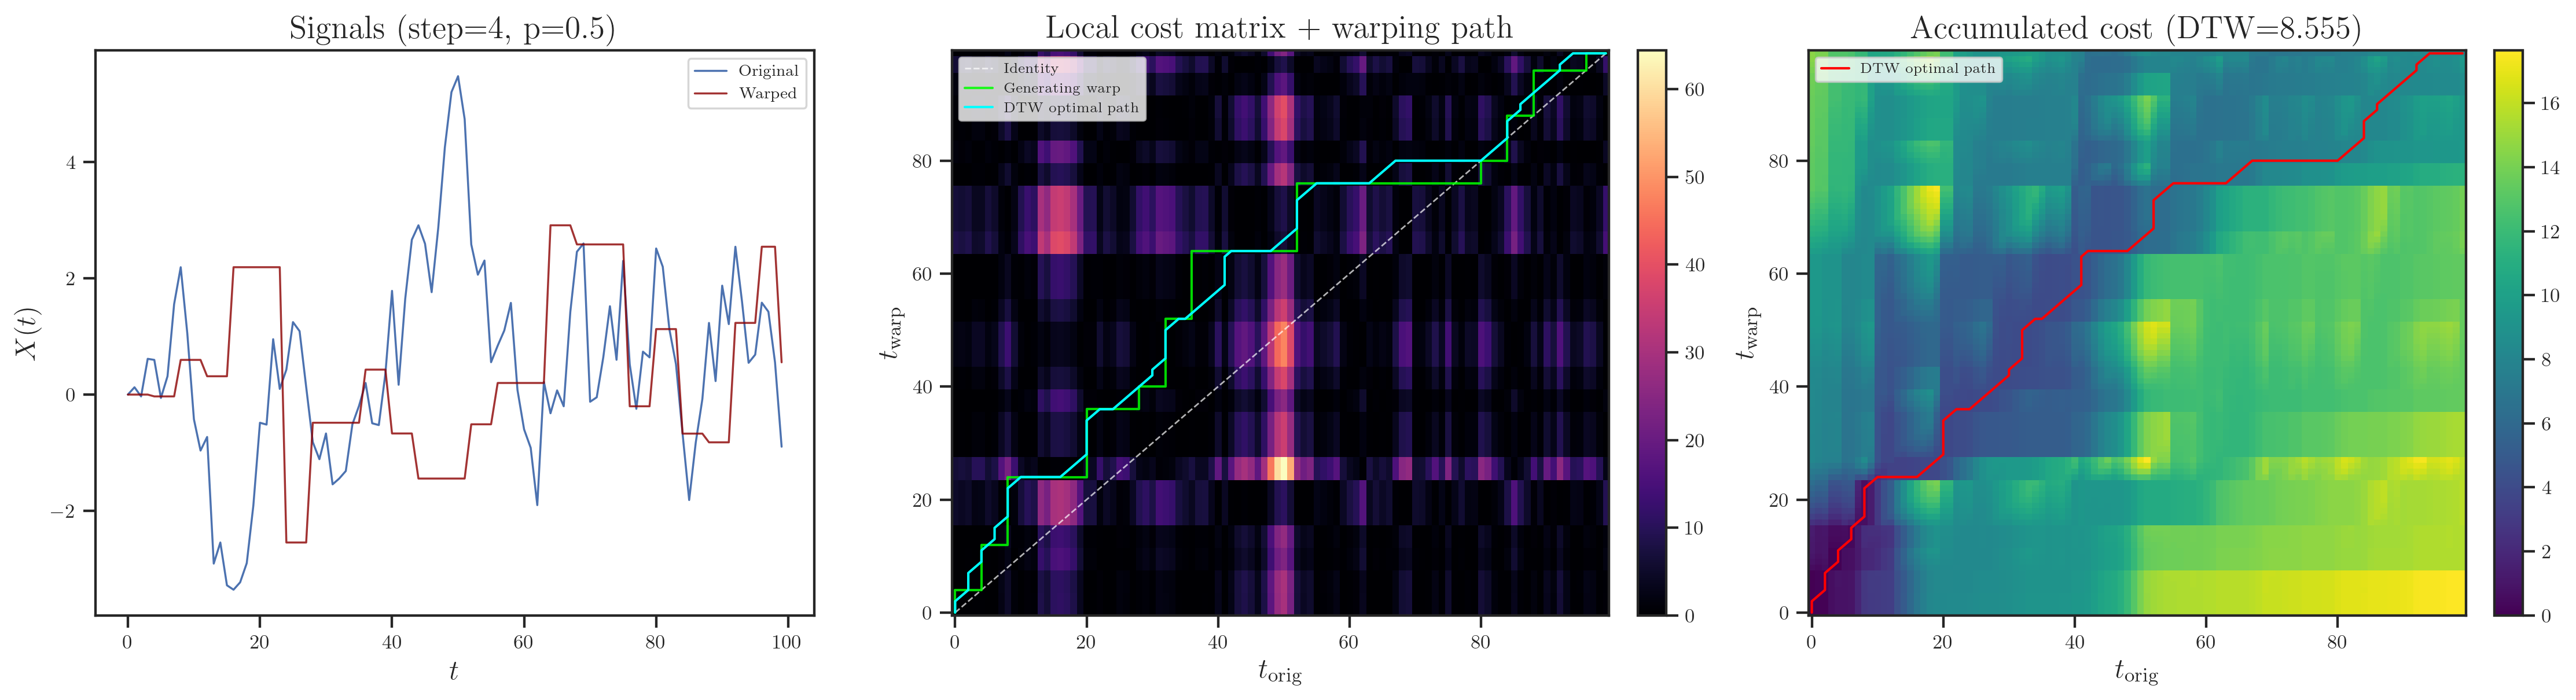

In [21]:
if __name__ == "__main__":
    T = 100
    step = 4
    p = 0.5

    X = generate_ar1(T=T, a=0.8, noise_std=1.0, seed=0)
    path_true = warp_path(T=T, p=p, step=step, seed=42)
    mapping = path_to_mapping(path_true, T=T)
    X_warp = warp_series(X, mapping)

    # Inferred DTW path between X and X_warp
    dtw_dist, accum_cost = dtw.warping_paths(X, X_warp, use_c=True)
    path_dtw = np.array(dtw.best_path(accum_cost), dtype=int)
    accum_cost_plot = accum_cost[1:, 1:]
    local_cost = (X[:, None] - X_warp[None, :]) ** 2

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=250)

    # Panel 1: time series
    ax = axes[0]
    ax.plot(X, label="Original", lw=1.0)
    ax.plot(X_warp, label="Warped", lw=1.0, alpha=0.8, color="darkred")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$X(t)$")
    ax.set_title(f"Signals (step={step}, p={p})")
    ax.legend(loc="upper right", fontsize=8)

    # Panel 2: classic local cost matrix + paths
    ax = axes[1]
    im1 = ax.imshow(local_cost.T, origin="lower", aspect="auto", cmap="magma")
    ax.plot([0, T - 1], [0, T - 1], "w--", lw=0.8, alpha=0.7, label="Identity")
    ax.plot(path_true[:, 0], path_true[:, 1], color="lime", lw=1.2, alpha=0.85, label="Generating warp")
    ax.plot(path_dtw[:, 0], path_dtw[:, 1], color="cyan", lw=1.2, label="DTW optimal path")
    ax.set_xlabel(rf"$t_{{\mathrm{{orig}}}}$")
    ax.set_ylabel(rf"$t_{{\mathrm{{warp}}}}$")
    ax.set_title("Local cost matrix + warping path")
    ax.legend(loc="upper left", fontsize=7)
    fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

    # Panel 3: accumulated cost matrix + DTW path
    ax = axes[2]
    im2 = ax.imshow(accum_cost_plot.T, origin="lower", aspect="auto", cmap="viridis")
    ax.plot(path_dtw[:, 0], path_dtw[:, 1], color="red", lw=1.2, label="DTW optimal path")
    ax.set_xlabel(rf"$t_{{\mathrm{{orig}}}}$")
    ax.set_ylabel(rf"$t_{{\mathrm{{warp}}}}$")
    ax.set_title(f"Accumulated cost (DTW={dtw_dist:.3f})")
    ax.legend(loc="upper left", fontsize=7)
    fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()


###### old DTW Viz

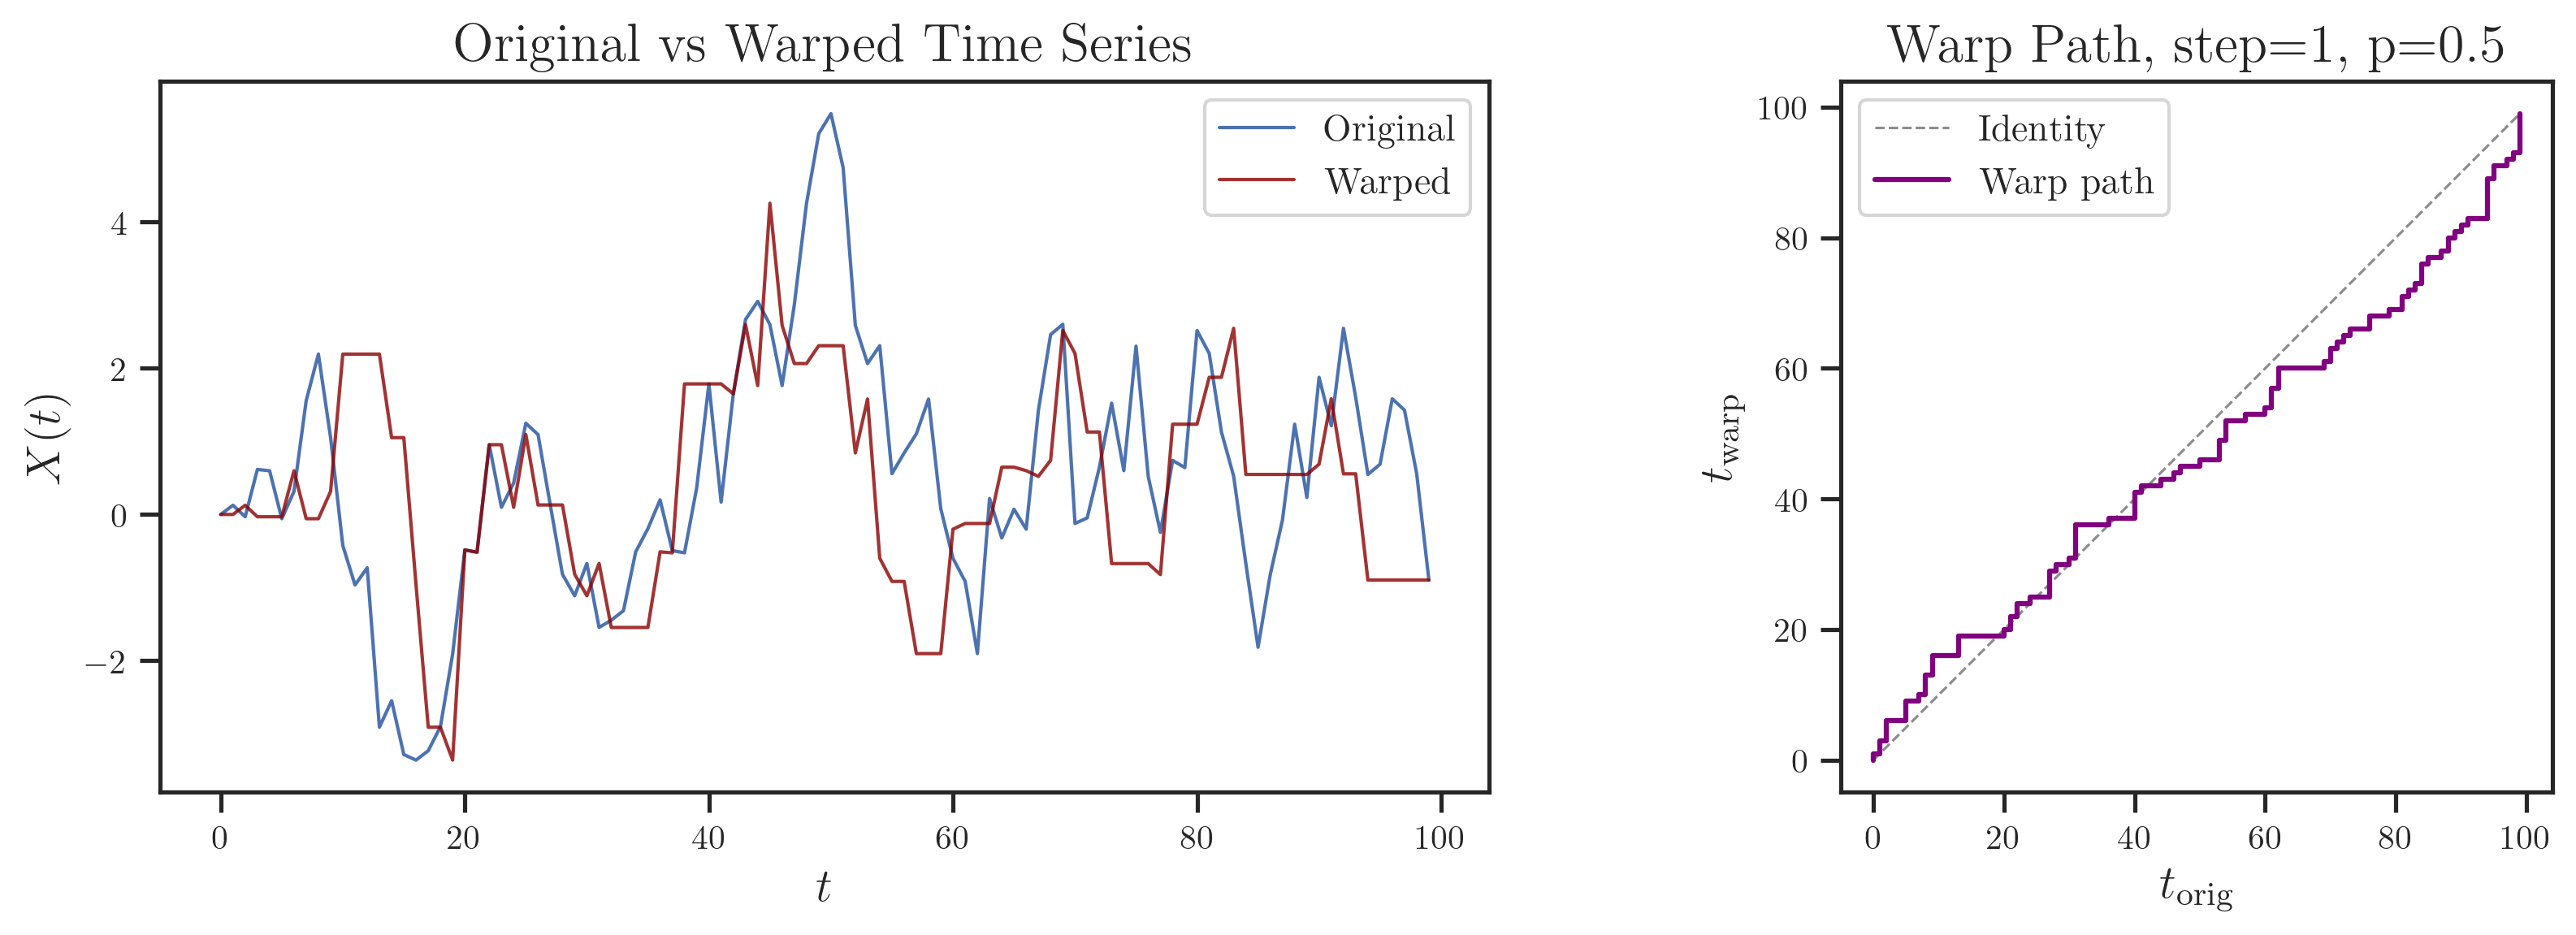

In [22]:

if __name__ == "__main__":
    T = 100
    step = 1
    p = 0.5
    
    X = generate_ar1(T=T, a=0.8, noise_std=1.0, seed=0)
    path = warp_path(T=T, p=p, step=step, seed=42)
    mapping = path_to_mapping(path, T=T)
    X_warp = warp_series(X, mapping)

    fig, axes = plot_warp(
        X,
        X_warp,
        path,
        figsize=(12, 4),
        dpi=300,
        path_title_suffix=f"step={step}, p={p}",
    )